In [1]:
suppressPackageStartupMessages(library(DESeq2, quietly=T))
suppressPackageStartupMessages(library(ggplot2, quietly=T))

# 1. データの読み込み
## 1-1. RNA-seqのデータ（カウントテーブル）を読み込む
データは、54,345遺伝子 x 50人 の生データ（raw count table）。

In [2]:
file_name <- "count_matrix.tsv"
data <- read.table(file_name, header = TRUE, row.names = 1)

In [3]:
data[1:5, 1:5]

,iPS_1,iPS_2,iPS_3,iPS_4,iPS_5
,<int>,<int>,<int>,<int>,<int>
DDX11L1,0,0,0,0,0
WASH7P,203,150,76,214,96
MIR6859-1,26,17,2,38,11
MIR1302-2HG,0,0,0,0,0
FAM138A,0,0,0,0,0


In [4]:
dim(data)

[1] 54356    50

## 1-2. メタデータの読み込み（性別を読み込む）

In [5]:
file_name <- "metadata.tsv"
metadata <- read.table(file_name, header = TRUE, row.names = 1)

In [10]:
head(metadata)

,is_female
,<chr>
iPS_1,False
iPS_2,True
iPS_3,False
iPS_4,True
iPS_5,True
iPS_6,True


In [11]:
dim(metadata)

[1] 50  1

# 2. DESeq2を用いて、PCAを行う
## 2-1. まずは、高発現の遺伝子を抽出する（低発現の遺伝子をデータから除外する）

In [12]:
min_read <- 1000
data <- data[ rowMeans(data) > min_read, ]
dim(data)

[1] 9864   50

## 2-2. DESeq2のデータに変換する

In [13]:
dds <- DESeqDataSetFromMatrix(
    countData = data,
    colData = metadata,
    design = ~ 1,
)

In [15]:
dds

class: DESeqDataSet 
dim: 9864 50 
metadata(1): version
assays(1): counts
rownames(9864): MTCO1P12 MTATP6P1 ... KDM5D EIF1AY
rowData names(0):
colnames(50): iPS_1 iPS_2 ... iPS_49 iPS_50
colData names(1): is_female

## 2-3. サンプル間で正規化、その後、vst（variance stabilizing transformation）を行う
DESeq2の正規化：size factorと呼ばれる係数を計算し、この係数を利用してカウントデータを正規化

In [16]:
vsd <- vst(dds, blind = TRUE)

## 2-4. PCAを行い、PC1とPC2をプロット

using ntop=500 top features by variance



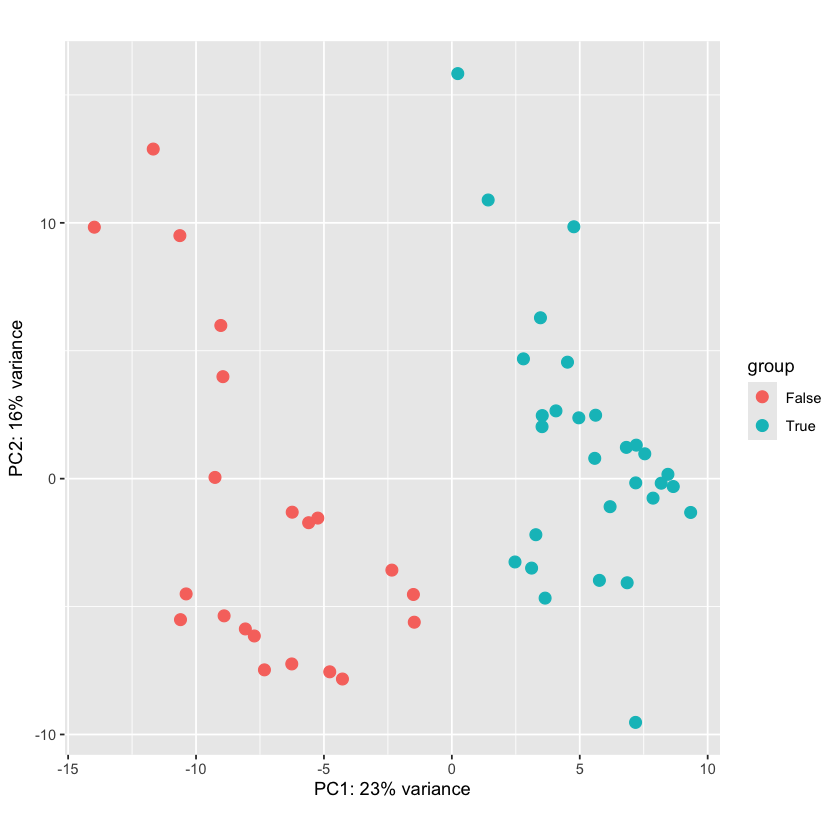

In [17]:
plotPCA(vsd, intgroup = "is_female")

# 3. PC2を説明する遺伝子は何なのか、を調べる
- 上記の解析は「お決まり」の解析で、チュートリアルを読めば、基本的には誰でもできる
- 一方、データを解釈する作業は、データごとに異なり、「お決まりのワークフロー」から外れることが多く、研究者側のスキルが試される
- DESeq2には、PC2を説明する遺伝子群を出力する機能がないので、DESeq2に頼らずに自分でPCAを実行することで、解釈性の高い解析を行う

## 3-1. DESeq2を用いずにPCAを行う

### 3-1-1. サンプル間バリアンスの計算

In [18]:
rv <- rowVars(assay(vsd))

### 3-1-2. サンプル間バリアンスがTOP500の遺伝子を抽出

In [19]:
keep <- order(rv, decreasing=TRUE)[1:500]
data <- assay(vsd)[keep, ]

In [20]:
dim(data)

[1] 500  50

### 3-1-3. PCAを行う（PC1とPC2のみ計算：rankを2に指定）

In [21]:
pca <- prcomp(t(data), rank = 2)

In [25]:
ls(pca)

[1] "center"   "rotation" "scale"    "sdev"     "x"

In [26]:
head(pca$x)

,PC1,PC2
iPS_1,-1.469275,-5.6113246
iPS_2,5.585137,0.7942455
iPS_3,-2.344565,-3.5748815
iPS_4,4.962735,2.3778800
iPS_5,5.767264,-3.9757230
iPS_6,6.852810,-4.0698459


In [27]:
head(pca$rotation)

,PC1,PC2
RPS4Y1,-0.33935591,-0.12062439
XIST,0.31086801,0.12788464
DDX3Y,-0.31297087,-0.10730347
POU5F1,-0.01888238,0.01931365
MEG3,0.02149191,-0.08745398
TXLNGY,-0.24250636,-0.07974385


## 3-2. PCAの結果をプロット

In [28]:
df <- data.frame(
    PC1 = pca$x[, 1],
    PC2 = pca$x[, 2],
    is_female = metadata
)

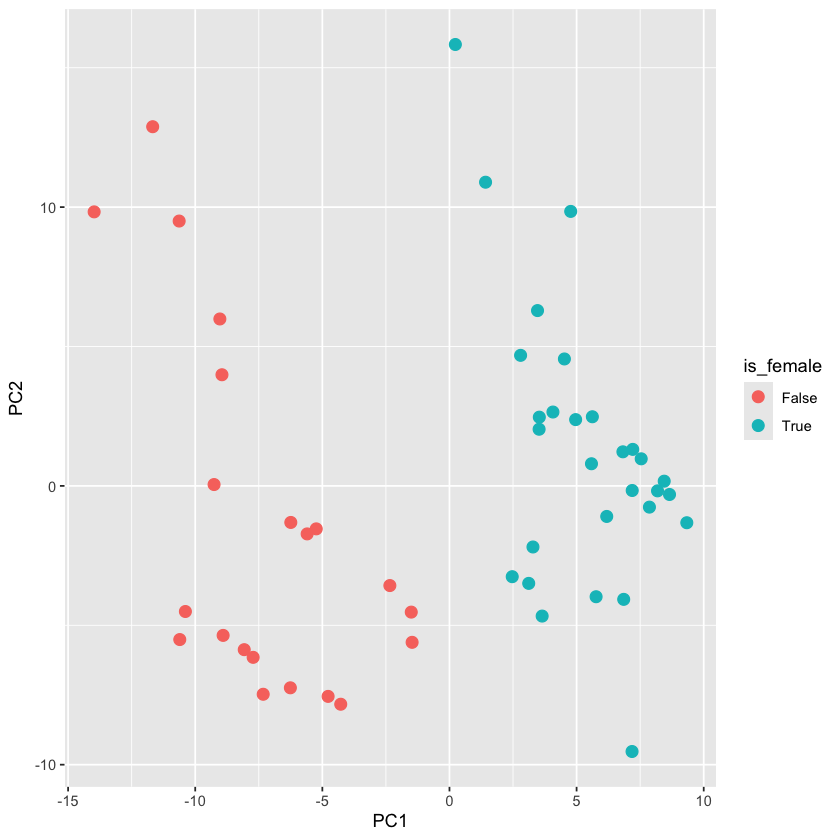

In [29]:
ggplot(df, aes(x = PC1, y = PC2, color = is_female)) + geom_point(size = 3)

## 3-3. PC2を説明する遺伝子（`pca$rotation`）を見にいく

In [31]:
loadings <- as.data.frame(pca$rotation)
top_50_genes <- loadings[order(loadings$PC2, decreasing=TRUE), ][1:50, ]

In [33]:
head(top_50_genes)

,PC1,PC2
,<dbl>,<dbl>
UTF1,-0.05542095,0.1538159
SP8,-0.03487657,0.1454257
RP11-69I8.2,-0.05706041,0.1364937
XIST,0.31086801,0.1278846
RP11-267L5.1,-0.07765960,0.1262833
NKX1-2,-0.03795007,0.1004336


In [34]:
rownames(top_50_genes)

[1] "UTF1"         "SP8"          "RP11-69I8.2"  "XIST"         "RP11-267L5.1"
 [6] "NKX1-2"       "CPT1A"        "FN1"          "CRLF1"        "THBS2"       
[11] "TUBB6"        "INA"          "ECEL1"        "ZNF516"       "TFAP2C"      
[16] "LEFTY1"       "TNRC18"       "NANOG"        "PDGFA"        "CCND1"       
[21] "AKAP7"        "RAI1"         "DSP"          "LRAT"         "NFATC1"      
[26] "SPG20"        "GLB1L3"       "ADAMTS16"     "P2RY1"        "STOX2"       
[31] "PCSK9"        "IQSEC2"       "NETO2"        "FERMT1"       "HES3"        
[36] "AK4"          "BMP7"         "PTCH1"        "LMO3"         "CDK14"       
[41] "PEG10"        "RIPK4"        "CALB1"        "PHLDB2"       "PLBD1"       
[46] "NEFL"         "TBC1D23"      "SOCS2"        "HIP1R"        "FAM102B"

↑ 「NANOG」があるのが確認できる

## 3-4. WebでのGO解析用（コピペ用）に、遺伝子名を出力

In [35]:
for (i in rownames(top_50_genes)) {
    cat(i, "\n")
}

UTF1 
SP8 
RP11-69I8.2 
XIST 
RP11-267L5.1 
NKX1-2 
CPT1A 
FN1 
CRLF1 
THBS2 
TUBB6 
INA 
ECEL1 
ZNF516 
TFAP2C 
LEFTY1 
TNRC18 
NANOG 
PDGFA 
CCND1 
AKAP7 
RAI1 
DSP 
LRAT 
NFATC1 
SPG20 
GLB1L3 
ADAMTS16 
P2RY1 
STOX2 
PCSK9 
IQSEC2 
NETO2 
FERMT1 
HES3 
AK4 
BMP7 
PTCH1 
LMO3 
CDK14 
PEG10 
RIPK4 
CALB1 
PHLDB2 
PLBD1 
NEFL 
TBC1D23 
SOCS2 
HIP1R 
FAM102B 


## 3-5. NANOGがPC2と関連（相関）していることを可視化

In [37]:
df$NANOG <- data["NANOG", ]

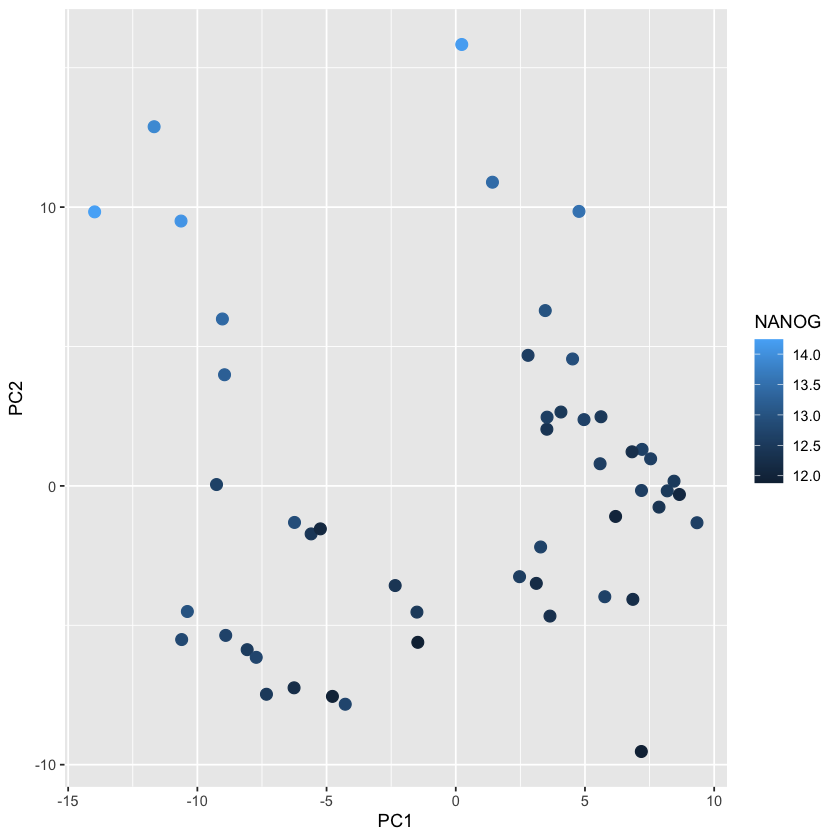

In [38]:
ggplot(df, aes(x = PC1, y = PC2, color = NANOG)) + geom_point(size = 3)

# まとめ
- PCAを行うことで、データに潜むパターンが見えた。そのパターンの解釈を行った。
- つまり、データ駆動的（data-driven）な解析を行った。
- その過程として、まずはお決まりの解析を行い、その後、必要に応じて独自の解析を織り交ぜた
- 今回は、未分化マーカとの相関を同定したが、あくまで「関連」であり「因果」ではない
- このような解析により、手持ちのデータの特性をきちんと理解し、特性に応じた解析が可能となる
- 例えば、未分化サンプルを除いて解析することや、分化状態を補正した解析を行う、など、解析の方針を立てることに役立つ